In [6]:
import cv2                       # OpenCV: la librería de visión por computadora
import numpy as np               # NumPy: maneja tablas de números (así se guarda una imagen)
import matplotlib.pyplot as plt  # Matplotlib: para dibujar imágenes y gráficos
# Esta línea es especial de Colab/Jupyter: hace que los gráficos aparezcan
# DENTRO del notebook, justo debajo de cada celda (y no en una ventana aparte).
%matplotlib inline
print("Todo listo. Las librerías se cargaron correctamente.")  # aviso de que ya podemos seguir

Todo listo. Las librerías se cargaron correctamente.


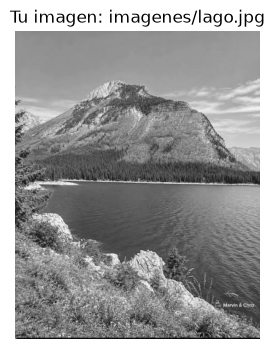

¡Listo! A partir de ahora se usará tu imagen. Tamaño: (501, 399)


In [7]:
#Se cambio para que funcione con JUPYTER
ruta = "imagenes/lago.jpg" 
img_color = cv2.imread(ruta, cv2.IMREAD_COLOR)
work_gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(5, 4))
plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)
plt.title(f"Tu imagen: {ruta}")
plt.axis("off")
plt.show()
print("¡Listo! A partir de ahora se usará tu imagen. Tamaño:", work_gray.shape)

# Visión por Computadora
## Laboratorio 2 — Representación digital y operaciones sobre píxeles
**Objetivo:** diagnosticar y mejorar una imagen usando lo de hoy. Completa cada paso siguiendo
los comentarios. Puedes usar la imagen de ejemplo o subir la tuya (Parte 2).

1. Muestra el **histograma** de tu imagen y di si es oscura, clara o de bajo contraste.

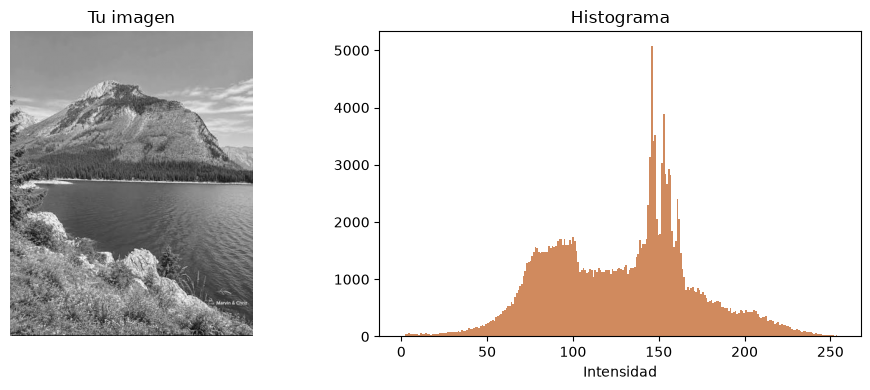

In [10]:
# ---------- Paso 1: histograma y diagnóstico ----------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1); plt.imshow(work_gray, cmap="gray", vmin=0, vmax=255)
plt.title("Tu imagen"); plt.axis("off")
plt.subplot(1, 2, 2); plt.hist(work_gray.ravel(), bins=256, range=(0,255), color="#D08A5E")
plt.title("Histograma"); plt.xlabel("Intensidad")
plt.tight_layout(); plt.show()

# Mi imagen es: de contraste normal, porque las barras del histograma cubren todo el rango de 0 a 250, aunque hay picos por el 90 y 150 aprox, 

2. Según tu diagnóstico, **mejórala**: si es oscura/clara ajusta el brillo; si es plana sube
   el contraste o ecualiza. Muestra el antes y el después.

# Dado que tiene partes mas oscuras como el bosque y el agua y mas claras como el cielo y la roca clara toca mejorarla ajustando el brillo

In [13]:
def ajustar(img, contraste=1.0, brillo=0): # Definimos la funcion
    # El metodo cv2.convertScaleAbs aplica:  salida = |contraste*img + brillo|  y recorta a 0..255.
    #   alpha = contraste (multiplica)   |   beta = brillo (suma)
    return cv2.convertScaleAbs(img, alpha=contraste, beta=brillo)

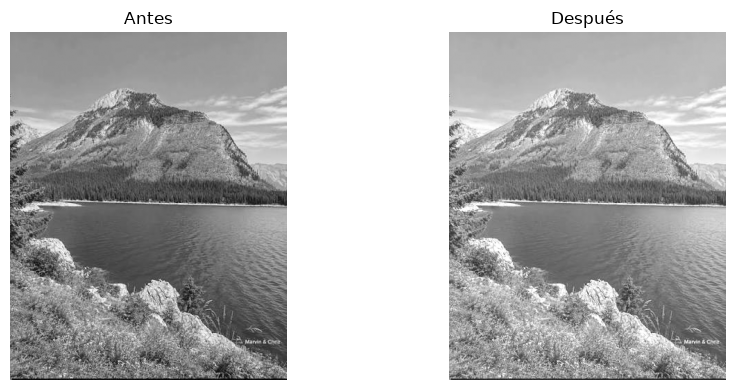

In [17]:
mejorada = ajustar(work_gray, contraste=1.0, brillo=30) 
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(work_gray, cmap="gray", vmin=0, vmax=255); ax[0].set_title("Antes");   ax[0].axis("off")
ax[1].imshow(mejorada,  cmap="gray", vmin=0, vmax=255); ax[1].set_title("Después"); ax[1].axis("off")
plt.tight_layout(); plt.show()

3. Aplica **umbralización de Otsu** a tu imagen mejorada.

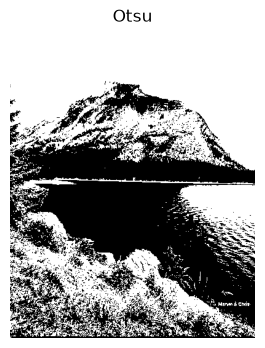

In [19]:
# ---------- umbralización de Otsu sobre tu imagen mejorada ----------
_, binaria_ej = cv2.threshold(mejorada, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
plt.figure(figsize=(4, 4)); plt.imshow(binaria_ej, cmap="gray", vmin=0, vmax=255)
plt.title("Otsu"); plt.axis("off"); plt.show()

4. Responde por escrito (celda de abajo): ¿por qué una red neuronal necesita la imagen
   normalizada a 0–1 en lugar de 0–255?

# Se normaliza a 0-1 porque con valores 0-255 los calculos seran muy grandes, lo que hace que el proceso de la imagen sea mas lento por los calculos sobre numeros altos. 